In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titlesize'] = 16

# Load dataset
df = pd.read_csv('Day14_Food_Delivery_Visualization_Dataset.csv')

# Ensure correct month ordering
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=months_order, ordered=True)
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_4871/3189270368.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_df = df.groupby('Month')[['Revenue', 'Orders']].mean().reset_index()


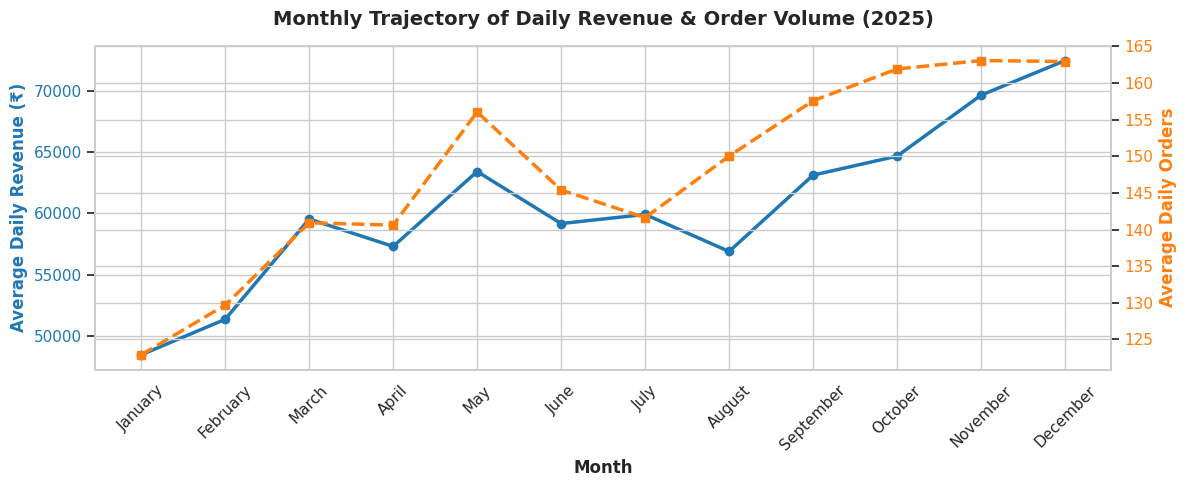

In [3]:
monthly_df = df.groupby('Month')[['Revenue', 'Orders']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Average Daily Revenue (₹)', color=color, fontweight='bold')
ax1.plot(monthly_df['Month'], monthly_df['Revenue'], color=color, marker='o', linewidth=2.5, label='Revenue (₹)')
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Average Daily Orders', color=color, fontweight='bold')
ax2.plot(monthly_df['Month'], monthly_df['Orders'], color=color, marker='s', linestyle='--', linewidth=2.5, label='Orders')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Trajectory of Daily Revenue & Order Volume (2025)', fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

/tmp/ipykernel_4871/230481657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=city_df, x='City', y='Revenue', palette='crest')


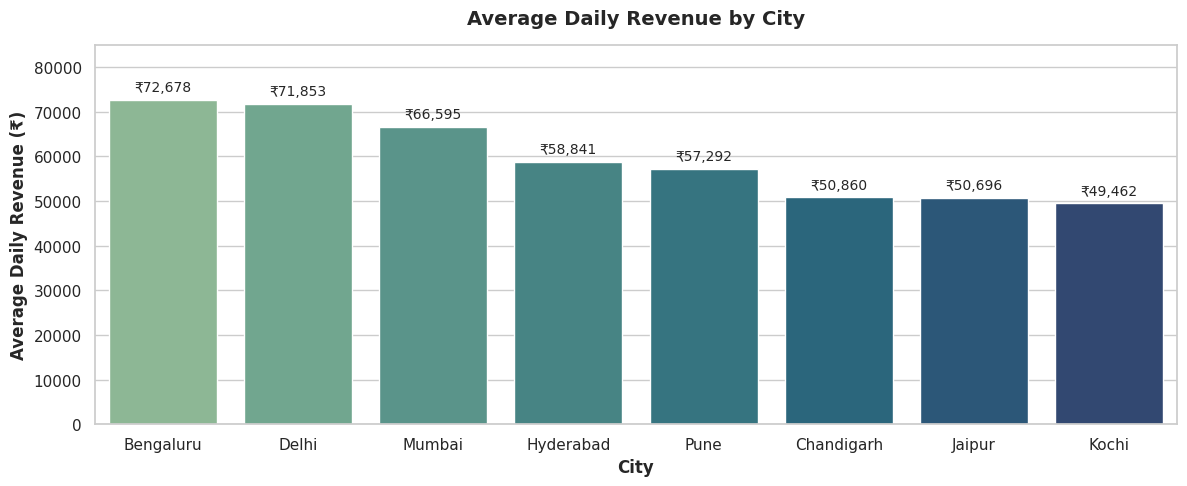

In [4]:
city_df = df.groupby('City')[['Revenue', 'Orders']].mean().sort_values(by='Revenue', ascending=False).reset_index()

plt.figure(figsize=(12, 5))
bars = sns.barplot(data=city_df, x='City', y='Revenue', palette='crest')

for p in bars.patches:
    bars.annotate(f'₹{p.get_height():,.0f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

plt.title('Average Daily Revenue by City', fontweight='bold', pad=15)
plt.xlabel('City', fontweight='bold')
plt.ylabel('Average Daily Revenue (₹)', fontweight='bold')
plt.ylim(0, 85000)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4871/1367052425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cuisine', y='Average_Order_Value', order=order_cuisine, palette='Set2')


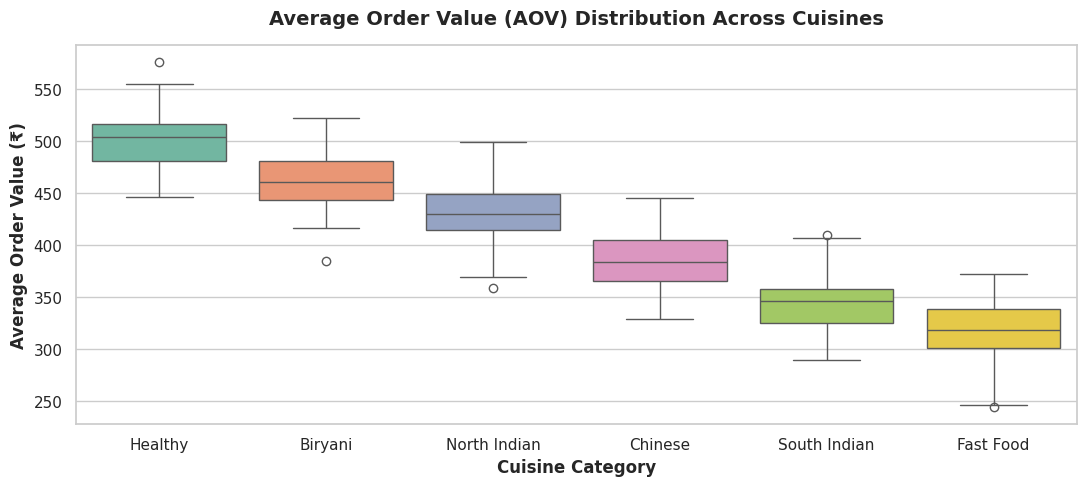

In [5]:
plt.figure(figsize=(11, 5))
order_cuisine = df.groupby('Cuisine')['Average_Order_Value'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='Cuisine', y='Average_Order_Value', order=order_cuisine, palette='Set2')
plt.title('Average Order Value (AOV) Distribution Across Cuisines', fontweight='bold', pad=15)
plt.xlabel('Cuisine Category', fontweight='bold')
plt.ylabel('Average Order Value (₹)', fontweight='bold')
plt.tight_layout()
plt.show()

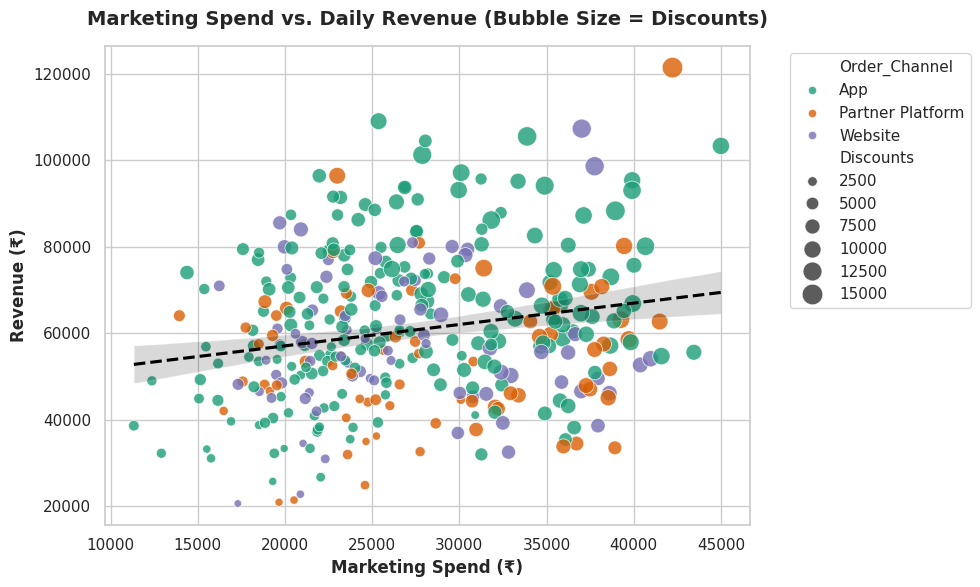

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Marketing_Spend', y='Revenue', hue='Order_Channel', size='Discounts',
                sizes=(30, 220), alpha=0.8, palette='Dark2')
sns.regplot(data=df, x='Marketing_Spend', y='Revenue', scatter=False, color='black', line_kws={'linestyle':'--'})

plt.title('Marketing Spend vs. Daily Revenue (Bubble Size = Discounts)', fontweight='bold', pad=15)
plt.xlabel('Marketing Spend (₹)', fontweight='bold')
plt.ylabel('Revenue (₹)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

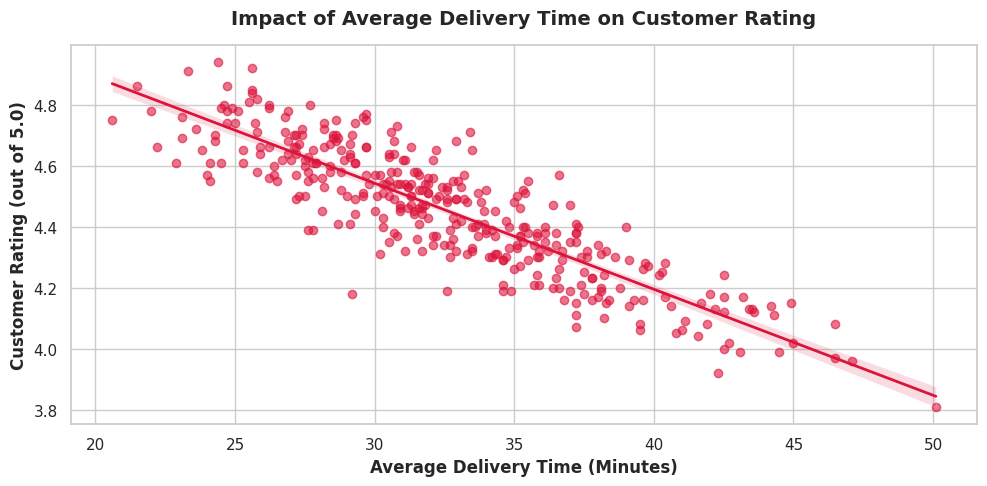

In [7]:
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='Avg_Delivery_Minutes', y='Customer_Rating',
            color='crimson', scatter_kws={'alpha':0.6}, line_kws={'linewidth':2})

plt.title('Impact of Average Delivery Time on Customer Rating', fontweight='bold', pad=15)
plt.xlabel('Average Delivery Time (Minutes)', fontweight='bold')
plt.ylabel('Customer Rating (out of 5.0)', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4871/936569073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Weather', y='Avg_Delivery_Minutes', palette='Blues', ax=axes[0], inner='quartile')
/tmp/ipykernel_4871/936569073.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Weather', y='Customer_Rating', palette='Reds_r', ax=axes[1], inner='quartile')


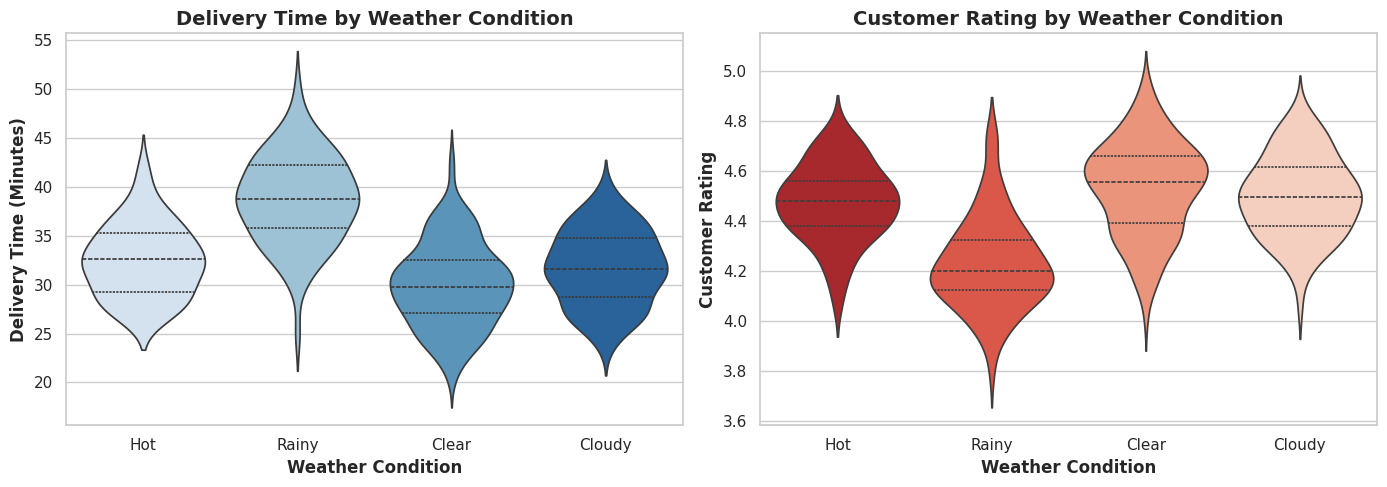

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='Weather', y='Avg_Delivery_Minutes', palette='Blues', ax=axes[0], inner='quartile')
axes[0].set_title('Delivery Time by Weather Condition', fontweight='bold')
axes[0].set_xlabel('Weather Condition', fontweight='bold')
axes[0].set_ylabel('Delivery Time (Minutes)', fontweight='bold')

sns.violinplot(data=df, x='Weather', y='Customer_Rating', palette='Reds_r', ax=axes[1], inner='quartile')
axes[1].set_title('Customer Rating by Weather Condition', fontweight='bold')
axes[1].set_xlabel('Weather Condition', fontweight='bold')
axes[1].set_ylabel('Customer Rating', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4871/2321680743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Order_Channel', palette='Set1', ax=axes[0])
/tmp/ipykernel_4871/2321680743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Order_Channel', y='Revenue', palette='Set1', ax=axes[1], errorbar=None)


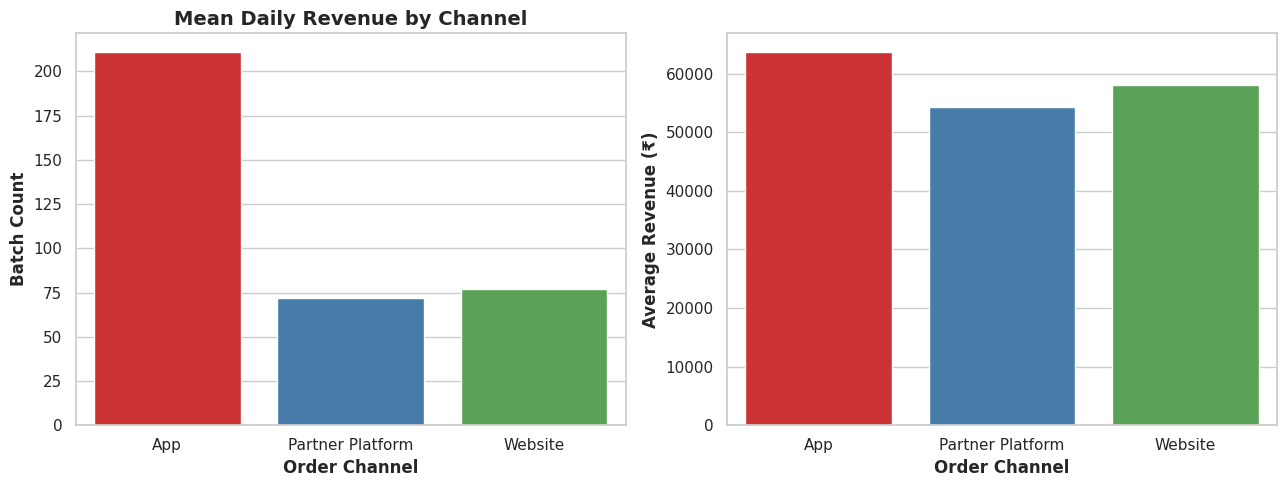

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Order_Channel', palette='Set1', ax=axes[0])
axes[0].set_title('Order Batch Distribution by Channel', fontweight='bold')
axes[0].set_xlabel('Order Channel', fontweight='bold')
axes[0].set_ylabel('Batch Count', fontweight='bold')

sns.barplot(data=df, x='Order_Channel', y='Revenue', palette='Set1', ax=axes[1], errorbar=None)
axes[0].set_title('Mean Daily Revenue by Channel', fontweight='bold')
axes[1].set_xlabel('Order Channel', fontweight='bold')
axes[1].set_ylabel('Average Revenue (₹)', fontweight='bold')

plt.tight_layout()
plt.show()

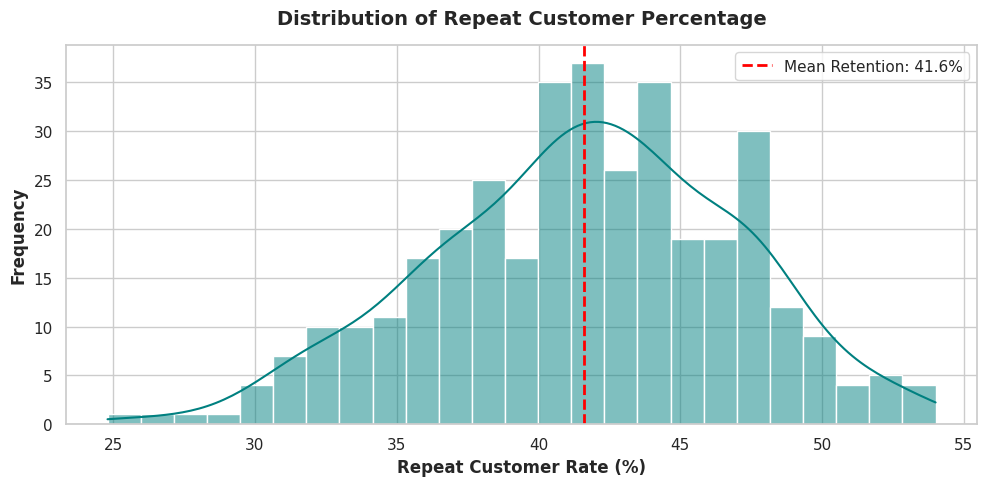

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Repeat_Customer_Percent'], kde=True, bins=25, color='teal')

mean_val = df['Repeat_Customer_Percent'].mean()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean Retention: {mean_val:.1f}%')

plt.title('Distribution of Repeat Customer Percentage', fontweight='bold', pad=15)
plt.xlabel('Repeat Customer Rate (%)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

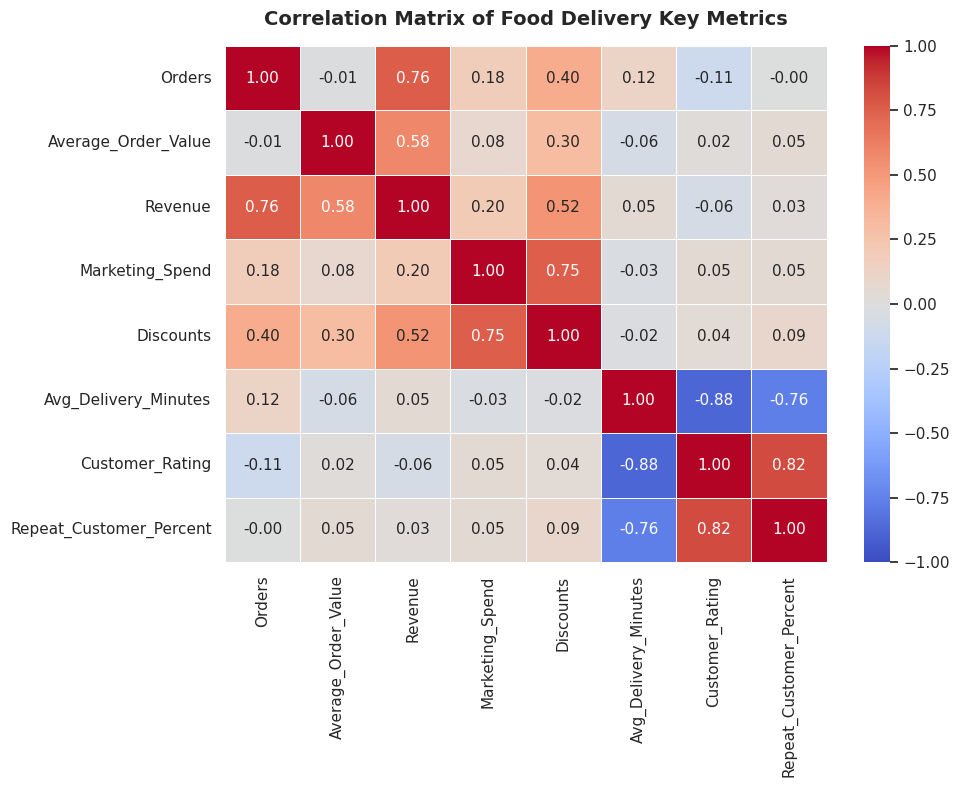

In [11]:
num_cols = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend',
            'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Matrix of Food Delivery Key Metrics', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()